## ▶️ ЭТАП 1 — Data Audit (как в работе аналитика)

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data.csv', encoding='ISO-8859-1')
df.head(10)
df.info() #Общую информацию о колонках и типах данных
df.describe() #Статистическое описание числовых данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [3]:
df.isna().sum() #Подсчет количесва пропущенных значений

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## 🔥 ЭТАП 2 — Data Cleaning (то, что делают настоящие аналитики)

In [4]:
rows_before = df.shape[0] # 1. Сохраним количество строк ДО очистки

In [5]:
df_clean = df[(df['UnitPrice'] > 0) & (df['Quantity'] > 0)] # 2. Фильтруем: Удаляем строки с ценой и Оставляем только положительное количество
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [6]:
len(df)

541909

In [7]:
rows_after = df_clean.shape[0] # 3. Считаем количество строк ПОСЛЕ
rows_after

530104

In [8]:
print(f"Строк до:{rows_before}")
print(f"Строк после:{rows_after}")
print(f"Удалено строк:{rows_before - rows_after}")

Строк до:541909
Строк после:530104
Удалено строк:11805


In [9]:
df_clean = df.dropna(subset=['CustomerID']) #Используй метод , чтобы удалить строки, где ID клиента отсутствует.

In [10]:
print(f"Количество строк после удаления отсутствующих ID: {rows_before - rows_after}")

Количество строк после удаления отсутствующих ID: 11805


## EDA

### Feature Engineering (Создание признаков) 🏗️

In [11]:
df_clean['Revenue'] = df['Quantity'] * df['UnitPrice']# Создай колонку Revenue
df_clean

C:\Users\user\AppData\Local\Temp\ipykernel_13456\3301921801.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Revenue'] = df['Quantity'] * df['UnitPrice']# Создай колонку Revenue


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France,16.60


In [12]:
df['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate']) #Преобразуй даты: используй pd.to_datetime(df_clean['InvoiceDate']), чтобы перезаписать колонку InvoiceDate
df.head(5) #Выведи первые 5 строк, чтобы убедиться, что новая колонка появилась и даты выглядят корректно.

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Анализ по странам (Top Markets) 🌍

In [13]:
country_revenue = df_clean.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
country_revenue

Country
United Kingdom    6767873.394
Netherlands        284661.540
EIRE               250285.220
Germany            221698.210
France             196712.840
Australia          137077.270
Switzerland         55739.400
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64

### Визуализация — Тренды продаж 📈

In [14]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['MonthYear'] = df_clean['InvoiceDate'].dt.to_period('M') #Создай колонку с месяцем
df_clean

C:\Users\user\AppData\Local\Temp\ipykernel_13456\2694690634.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
C:\Users\user\AppData\Local\Temp\ipykernel_13456\2694690634.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['MonthYear'] = df_clean['InvoiceDate'].dt.to_period('M') #Создай колонку с месяцем


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,MonthYear
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,2011-12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,2011-12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,2011-12


In [15]:
import matplotlib.pyplot as plt

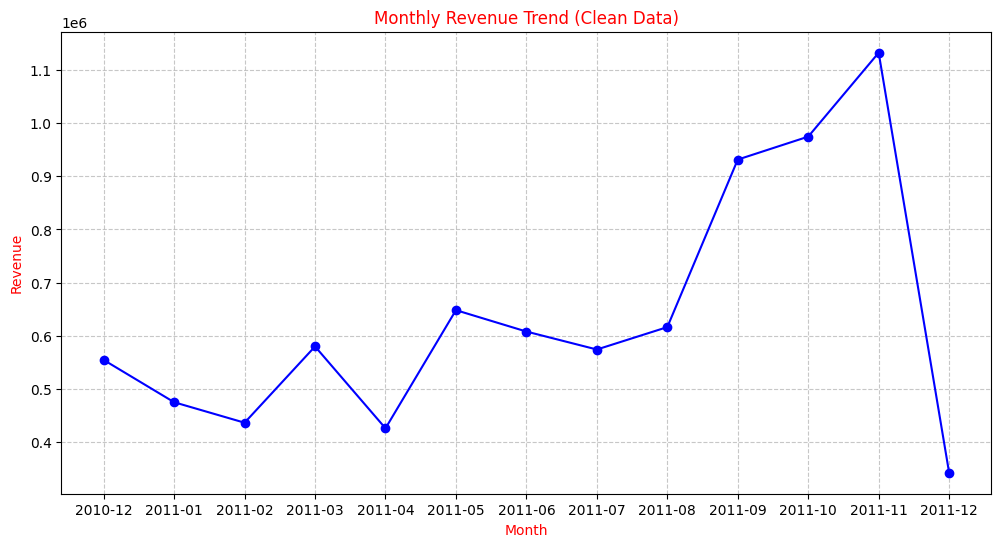

In [27]:
monthly_sales = df_clean.groupby('MonthYear')['Revenue'].sum() # Группируем выручку по месяцам

plt.figure(figsize=(12,6)) # Строим график
monthly_sales.index = monthly_sales.index.astype(str) # Превращаем в строку для корректного отображения
plt.plot(monthly_sales.index,monthly_sales.values, marker='o', linestyle='-', color='b')
plt.title('Monthly Revenue Trend (Clean Data)', color='r')
plt.xlabel('Month', color='r')
plt.ylabel('Revenue',color='r')
#plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [26]:
print(df_clean['InvoiceDate'].max())

2011-12-09 12:50:00


### RFM-анализ (Кого мы любим больше всех?) 👑

In [30]:
import datetime as dt

# 1. Создаем точку отсчета ("Сегодня")
# Мы берем самую последнюю дату в данных и добавляем 1 день
today = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

# 2. Создаем таблицу RFM
rfm = df_clean.groupby('CustomerID').agg({
    # Для Recency: берем самую позднюю дату покупки клиента и вычитаем ее из "сегодня"
    'InvoiceDate': lambda x: (today - x.max()).days,
    # Для Frequency: просто считаем количество строк (чеков) клиента
    'InvoiceNo': 'count',
    # Для Monetary: складываем всю его колонку Revenue
    'Revenue': 'sum'
})

# 3. Даем колонкам понятные имена Давность Частота Деньги
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


#### Шаг: Назначаем оценки (Scoring)

In [31]:
# 1. Оценка Recency (Давность): чем МЕНЬШЕ дней прошло, тем ВЫШЕ балл (поэтому labels=[5, 4, 3, 2, 1])
rfm['R'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# 2. Оценка Frequency (Частота): чем БОЛЬШЕ покупок, тем ВЫШЕ балл
# Мы используем rank(method='first'), чтобы избежать ошибок, если у многих клиентов одинаковое кол-во покупок
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# 3. Оценка Monetary (Деньги): чем БОЛЬШЕ сумма, тем ВЫШЕ балл
rfm['M'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm.head()

,Recency,Frequency,Monetary,R,F,M
CustomerID,,,,,,
12346.0,326,2,0.00,1,1,1
12347.0,2,182,4310.00,5,5,5
12348.0,75,31,1797.24,2,3,4
12349.0,19,73,1757.55,4,4,4
12350.0,310,17,334.40,1,2,2


#### Шаг: Создаем сегменты (Пошагово)

In [ ]:
# Мы объединим наши оценки в одну строку (например, "555" или "115") и дадим им человеческие названия.

In [34]:
# 1.Склеиваем оценки: Сначала нам нужно превратить отдельные оценки в одну комбинацию.
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str) # Мы превращаем числа в текст (str) и складываем их

In [35]:
# 2.Даем имена (Словарь сегментов): Это самый творческий и важный этап. Мы пропишем логику: кто есть кто.
# Функция, которая дает название на основе оценки R и F
# (Для простоты мы пока возьмем только две буквы, это стандартная практика)
def segment_me(df):
    r = df['R']
    f = df['F']
    
    if r == 5 and f == 5:
        return 'Champions (Лучшие)'
    elif r >= 4 and f >= 4:
        return 'Loyal Customers (Лояльные)'
    elif r >= 3 and f >= 1:
        return 'Potential Loyalist (Перспективные)'
    elif r <= 2 and f >= 4:
        return 'At Risk (В зоне риска)'
    elif r <= 2 and f <= 2:
        return 'Hibernating (Спящие)'
    else:
        return 'Others (Прочие)'

# Применяем функцию к каждой строке таблицы
rfm['Segment'] = rfm.apply(segment_me, axis=1)

# Считаем, сколько человек попало в каждую группу
print(rfm['Segment'].value_counts())

Segment
Potential Loyalist (Перспективные)    1527
Hibernating (Спящие)                  1066
Loyal Customers (Лояльные)             717
Champions (Лучшие)                     393
Others (Прочие)                        364
At Risk (В зоне риска)                 305
Name: count, dtype: int64


### Шаг: Визуализация сегментов (Добавляем красок в отчет) 🎨

<function matplotlib.pyplot.show(close=None, block=None)>

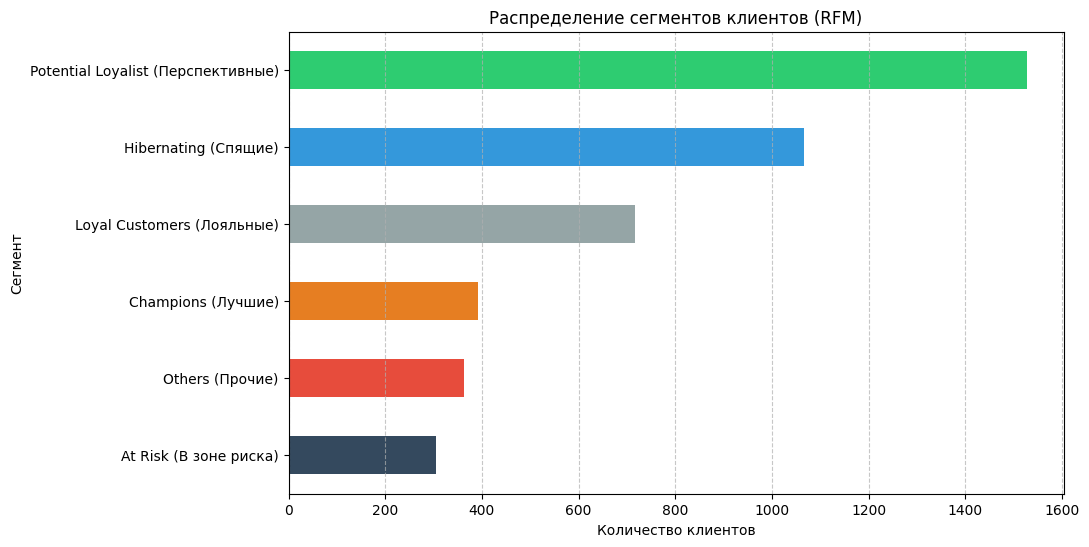

In [39]:
import matplotlib.pyplot as plt

# 1. Подготовим данные: считаем количество клиентов в каждом сегменте
segment_counts = rfm['Segment'].value_counts()

# 2. Создаем фигуру (холст) для графика
plt.figure(figsize=(10,6))

# 3. Строим горизонтальный график (barh — bar horizontal)
# Мы используем цвета, чтобы подчеркнуть важность
colors = ['#2ecc71', '#3498db', '#95a5a6', '#e67e22', '#e74c3c', '#34495e']
segment_counts.plot(kind='barh', color=colors)

# 4. Добавляем "красоту" и подписи
plt.title('Распределение сегментов клиентов (RFM)')
plt.xlabel('Количество клиентов')
plt.ylabel('Сегмент')
plt.gca().invert_yaxis() # Чтобы самые крупные группы были наверху
plt.grid(axis='x', linestyle='--', alpha=0.7) # Добавляем сеточку только по оси X
plt.show

### Шаг: Итоговый отчет (Business Insights) 📝

In [40]:
1. Key Metrics (Ключевые показатели)
Total Revenue: (напиши общую сумму выручки, которую мы получили после очистки).

Total Customers: (сколько уникальных CustomerID осталось).

Top Country: United Kingdom (с долей около 80-90% выручки).

2. Customer Segmentation (RFM)
Biggest Group: Potential Loyalists (1527 человек).

Recommendation: Предложить им программу лояльности, чтобы перевести в разряд Champions.

Critical Group: Hibernating (Спящие).

Recommendation: Провести реактивацию через email-рассылку с персональной скидкой.

3. Data Quality Notes (Важно для Junior!)
Обнаружены и удалены аномалии (отрицательные цены и количество).

Данные за декабрь 2011 года не полные (до 9 декабря), что объясняет визуальное падение продаж на графиках.

SyntaxError: invalid syntax (2414616733.py, line 1)